<a href="https://colab.research.google.com/github/fahim12345c/Deep-Learning/blob/main/Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Original prediction: [('n02077923', 'sea_lion', np.float32(0.9823716))]


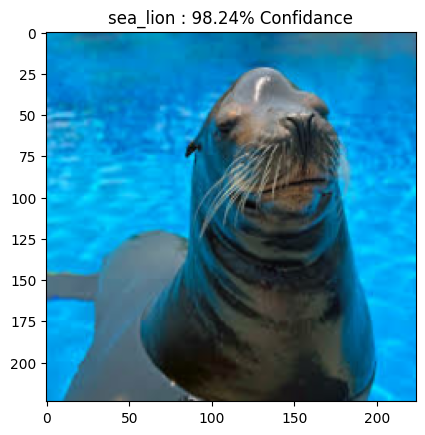

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

# Load pre-trained model
pretrained_model = tf.keras.applications.MobileNetV2(include_top=True, weights='imagenet')
pretrained_model.trainable = False

# ImageNet labels
decode_predictions = tf.keras.applications.mobilenet_v2.decode_predictions


def preprocess(image):
  image = tf.cast(image, tf.float32)
  image = tf.image.resize(image, (224, 224))
  image = tf.keras.applications.inception_v3.preprocess_input(image)
  image = image[None, ...]
  return image

# Load and preprpgocess an image
image_path = tf.keras.utils.get_file('sea_lion.jpg', 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRx5RY3qhvZyAoKyi3Es0b3jDooeNP4sFB1iQ&s')
image_raw = tf.io.read_file(image_path)
image = tf.image.decode_image(image_raw)

image = preprocess(image)
image_probs = pretrained_model.predict(image)

# Make initial prediction
preds = pretrained_model.predict(image)
print("Original prediction:", decode_predictions(preds, top=1)[0])

# Helper function to extract labels from probability vector
def get_imagenet_label(probs):
  return decode_predictions(probs, top=1)[0][0]

plt.figure()
plt.imshow(image[0] * 0.5 + 0.5)
_, image_class, class_confidance = get_imagenet_label(preds)
plt.title('{} : {:.2f}% Confidance'.format(image_class, class_confidance*100))
plt.show()
plt.close()



In [ ]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

def create_adversarial_pattern(input_image, input_label):
  with tf.GradientTape() as tape:
    tape.watch(input_image)
    prediction = pretrained_model(input_image)
    loss = loss_object(input_label, prediction)

  # Get the gradients of the loss w.r.t to the input image.
  gradient = tape.gradient(loss, input_image)
  # Get the sign of the gradients to create the perturbation
  signed_grad = tf.sign(gradient)
  return signed_grad

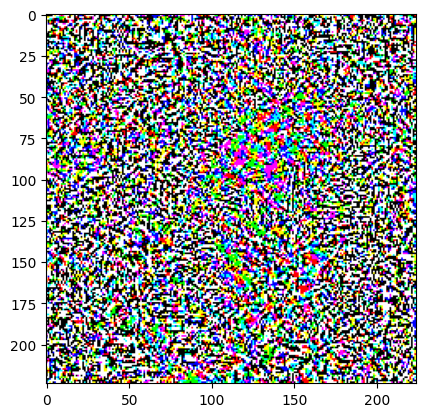

In [ ]:
# Get the input label of the image.
labrador_retriever_index = 587
label = tf.one_hot(labrador_retriever_index, preds.shape[-1])
label = tf.reshape(label, (1, preds.shape[-1]))

perturbations = create_adversarial_pattern(image, label)
plt.imshow(perturbations[0] * 0.5 + 0.5);

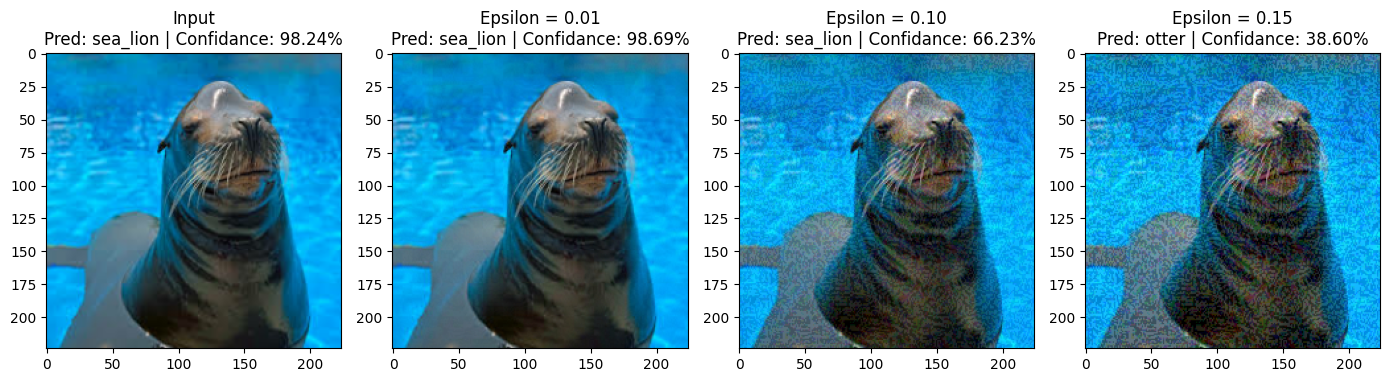

In [ ]:
epsilons = [0, 0.01, 0.1, 0.15]
descriptions = [('Epsilon = {:0.2f}'.format(eps) if eps else 'Input') for eps in epsilons]

plt.figure(figsize=(14, 4))

for i, eps in enumerate(epsilons):
    adv_x = image + eps * perturbations
    adv_x = tf.clip_by_value(adv_x, -1, 1)

    # Model prediction
    pred = pretrained_model(adv_x)
    label = get_imagenet_label(pred)

    # Plot
    plt.subplot(1, 4, i + 1)
    plt.imshow(adv_x[0] * 0.5 + 0.5)
    plt.title(f"{descriptions[i]}\nPred: {label[1]} | Confidance: {label[2]*100:.2f}%")
    # plt.axis('off')
plt.tight_layout()
plt.show()
plt.close()

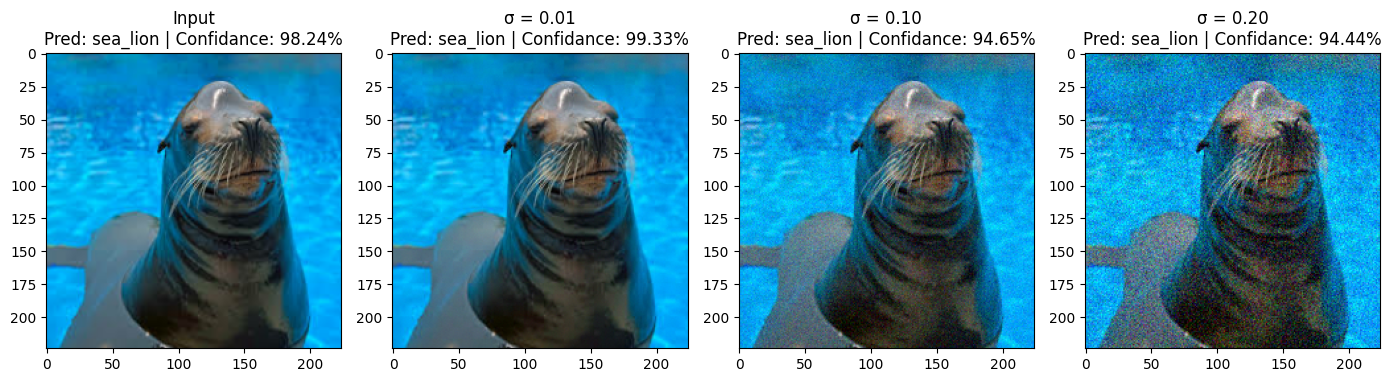

In [ ]:
sigmas = [0, 0.01, 0.1, 0.2]
descriptions = [f"σ = {s:.2f}" if s else "Input" for s in sigmas]

plt.figure(figsize=(14, 4))

for i, sigma in enumerate(sigmas):
    noise = tf.random.normal(shape=image.shape, mean=0.0, stddev=sigma)
    noisy_img = image + noise
    noisy_img = tf.clip_by_value(noisy_img, -1, 1)

    # Model prediction
    pred = pretrained_model(noisy_img)
    label = get_imagenet_label(pred)

    # Plot
    plt.subplot(1, 4, i + 1)
    plt.imshow(noisy_img[0] * 0.5 + 0.5)
    plt.title(f"{descriptions[i]}\nPred: {label[1]} | Confidance: {label[2]*100:.2f}%")
    # plt.axis('off')

plt.tight_layout()
plt.show()
plt.close()
